# Caso I · 04 Benchmark medido — pandas vs polars vs duckdb

> _Tutorial · Caso de uso: **I — Spark vs Pandas** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

**Medir empíricamente** (no simular) tiempos de tres motores tabulares single-node modernos: pandas, polars, duckdb. Reportar mediana de 5 runs + varianza. Decidir cuándo cada motor es la opción correcta.


## 2. Qué se aprende

- Cómo medir tiempos correctamente (`perf_counter`, warmup, mediana).
- Diferencias prácticas entre eager (pandas) y lazy (polars, duckdb).
- Por qué el espacio de decisión moderno NO es solo pandas vs Spark.
- Cuándo el coste de startup de Spark se amortiza.


## 3. Contexto del caso de uso

Recomendación final del proyecto.


## 4. Relación con CENTINELA+

Decisión de stack en producción.


## 5. Relación con Medallion

Oro: análisis.


## 6. Datos de entrada

Mock BDG2 escalado a varios tamaños.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica.


## 9. Carga de datos o mock

Generamos datasets sintéticos a 3 tamaños (10⁴, 10⁵, 10⁶) para que el benchmark se ejecute en < 60 s en una laptop.


In [2]:
import time

import polars as pl
try:
    import duckdb
    HAS_DUCKDB = True
except ImportError:
    HAS_DUCKDB = False

def make_synthetic_table(n_rows: int, seed: int = SEED) -> pd.DataFrame:
    g = np.random.default_rng(seed)
    return pd.DataFrame({
        "building_id": g.choice([f"b_{i:04d}" for i in range(50)], size=n_rows),
        "timestamp": pd.date_range("2024-01-01", periods=n_rows, freq="h"),
        "power_kw": g.gamma(2, 30, size=n_rows),
        "t_outdoor": 12 + 12 * np.sin(np.linspace(0, 4 * np.pi, n_rows)) + g.normal(0, 2, n_rows),
    })

sizes = [10_000, 100_000, 1_000_000]
print({n: f"{n / 1e6:.1f}M filas" for n in sizes})


{10000: '0.0M filas', 100000: '0.1M filas', 1000000: '1.0M filas'}


## 10. Exploración paso a paso

Definimos las **operaciones** a benchmarkar — todas devuelven el mismo resultado (groupby+agg) para que las comparaciones sean justas.


In [3]:
def op_pandas(df_pd: pd.DataFrame) -> pd.Series:
    return df_pd.groupby("building_id")["power_kw"].mean().sort_index()

def op_polars(df_pl: pl.DataFrame) -> pd.Series:
    out = (
        df_pl.group_by("building_id").agg(pl.col("power_kw").mean())
              .sort("building_id").to_pandas()
    )
    return out.set_index("building_id")["power_kw"]

def op_duckdb(df_pd: pd.DataFrame) -> pd.Series:
    if not HAS_DUCKDB:
        return pd.Series(dtype=float)
    con = duckdb.connect()
    con.register("t", df_pd)
    res = con.execute(
        "SELECT building_id, AVG(power_kw) AS power_kw FROM t GROUP BY building_id ORDER BY building_id"
    ).df()
    con.close()
    return res.set_index("building_id")["power_kw"]


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

**Benchmark medido** con 1 warmup + 5 runs por (engine, size). Reportamos mediana y MAD (median absolute deviation).


In [4]:
def time_runs(fn, *args, runs: int = 5, warmup: int = 1):
    for _ in range(warmup):
        fn(*args)
    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        fn(*args)
        ts.append(time.perf_counter() - t0)
    arr = np.array(ts)
    return float(np.median(arr)), float(np.median(np.abs(arr - np.median(arr))))

results = []
for n in sizes:
    df_pd = make_synthetic_table(n)
    df_pl = pl.from_pandas(df_pd)
    med_pd, mad_pd = time_runs(op_pandas, df_pd)
    med_pl, mad_pl = time_runs(op_polars, df_pl)
    med_dd, mad_dd = (time_runs(op_duckdb, df_pd) if HAS_DUCKDB else (float("nan"), float("nan")))
    results.append({
        "n": n,
        "pandas_s": round(med_pd, 4), "pandas_mad": round(mad_pd, 4),
        "polars_s": round(med_pl, 4), "polars_mad": round(mad_pl, 4),
        "duckdb_s": round(med_dd, 4) if not np.isnan(med_dd) else None,
        "duckdb_mad": round(mad_dd, 4) if not np.isnan(mad_dd) else None,
    })
bench = pd.DataFrame(results)
print(bench.to_string(index=False))


      n  pandas_s  pandas_mad  polars_s  polars_mad  duckdb_s  duckdb_mad
  10000    0.0010      0.0001    0.0027      0.0003    0.0296      0.0015
 100000    0.0062      0.0006    0.0055      0.0003    0.0395      0.0009
1000000    0.0595      0.0082    0.0081      0.0006    0.0493      0.0013


## 13. Visualizaciones explicativas

Tiempos en escala log-log + speedup vs pandas.


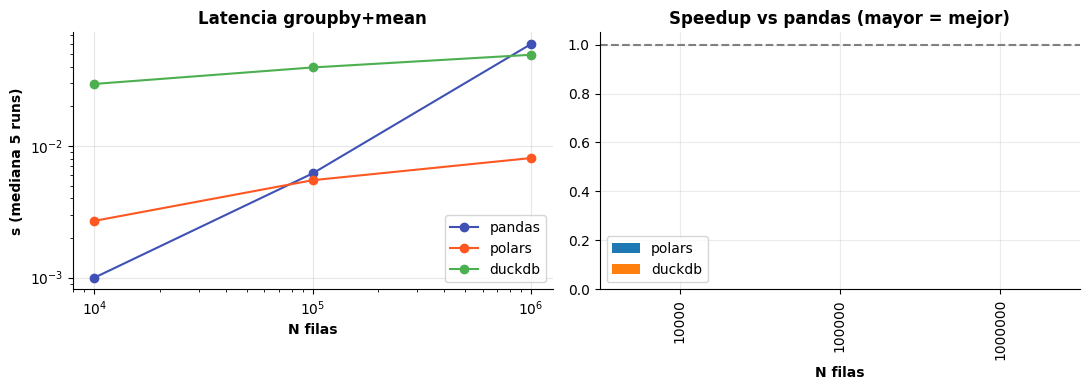

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(bench["n"], bench["pandas_s"], marker="o", label="pandas", color="#3F51B5")
axes[0].plot(bench["n"], bench["polars_s"], marker="o", label="polars", color="#FF5722")
if HAS_DUCKDB:
    axes[0].plot(bench["n"], bench["duckdb_s"], marker="o", label="duckdb", color="#4CAF50")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("N filas"); axes[0].set_ylabel("s (mediana 5 runs)")
axes[0].set_title("Latencia groupby+mean")
axes[0].legend(); axes[0].grid(alpha=0.3)

speedup = pd.DataFrame({
    "polars": (bench["pandas_s"] / bench["polars_s"]).round(2),
    "duckdb": (bench["pandas_s"] / bench["duckdb_s"]).round(2) if HAS_DUCKDB else 1,
}, index=bench["n"])
speedup.plot.bar(ax=axes[1])
axes[1].set_title("Speedup vs pandas (mayor = mejor)")
axes[1].axhline(1.0, color="gray", linestyle="--")
axes[1].set_xlabel("N filas")
plt.tight_layout()


## 14. Validaciones

Los tres motores deben dar **resultados numéricamente equivalentes** (equivalencia funcional) y los tiempos deben ser positivos.


In [6]:
df_check = make_synthetic_table(10_000)
r_pd = op_pandas(df_check)
r_pl = op_polars(pl.from_pandas(df_check))
joined = pd.concat([r_pd, r_pl], axis=1, keys=["pandas", "polars"])
diff = (joined["pandas"] - joined["polars"]).abs().max()
assert diff < 1e-6, f"pandas y polars discrepan: max diff = {diff}"
if HAS_DUCKDB:
    r_dd = op_duckdb(df_check)
    diff2 = (r_pd - r_dd).abs().max()
    assert diff2 < 1e-6, f"pandas y duckdb discrepan: max diff = {diff2}"
assert (bench["pandas_s"] > 0).all() and (bench["polars_s"] > 0).all()
print("Validaciones OK · resultados numéricamente equivalentes y tiempos positivos")


Validaciones OK · resultados numéricamente equivalentes y tiempos positivos


## 15. Errores comunes

1. **No hacer warmup**: el primer run incluye JIT/import overhead → outlier que sesga la mediana.
2. **Reportar 1 sola medición**: alta varianza → reportar 5+ con MAD.
3. **Comparar resultados sin verificar equivalencia**: los engines pueden diferir en orden o tipo (e.g. nan handling).
4. **Comparar Spark single-node con pandas**: el coste de startup de Spark es ~1.5 s, casi nunca se amortiza para < 1M filas.
5. **No publicar el dataset**: el benchmark debe ser reproducible — publicar `make_synthetic_table` o el script.


## 16. Ejercicios propuestos

1. Añade `pyspark` con `master('local[*]')` al benchmark. ¿Cuándo comienza a ganar? Rúbrica: encontrar el N donde Spark < polars.
2. Sustituye groupby+mean por una **operación shuffle-heavy** (e.g. join entre dos tablas de 1M filas). ¿Polars sigue ganando?
3. Mide consumo de memoria con `tracemalloc` — pandas suele consumir 3-5× lo que polars/duckdb. Verifícalo y reporta.


## 17. Cómo se reutiliza con datos reales

Reemplazar `make_synthetic_table` por la lectura del CSV BDG2 (53M filas) y re-ejecutar. Ojo con la memoria: pandas necesitará ~16 GB RAM, polars/duckdb ~4 GB.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `10_case_J_traffic_yolo/01_captura_imagenes_dgt.ipynb`.
- Documento web del caso: `docs/use-cases/case-i-spark-pandas.md`.


## 19. Marco teórico (nivel doctoral)

### Modelo de coste pandas (single-node)

$$
T_{pandas}(N) = O(N) \quad \text{si} \quad N \cdot d \cdot 8 \text{ bytes} \leq \text{RAM}
$$

con OOM cuando se supera la RAM disponible.

### Modelo de coste Spark (distribuido)

$$
T_{Spark}(N, p) = T_{startup} + \frac{N}{p} \cdot t_{cpu} + O(\log p) \cdot t_{shuffle}
$$

con $p$ paralelismo, $t_{shuffle}$ coste red por partición.

### Punto de cruce

$$
N^* = \frac{T_{startup} \cdot p}{t_{cpu}^{pandas} - t_{cpu}^{spark}}
$$

A escala $N \gtrsim 10^7$ filas con ops shuffle-heavy, Spark domina; por
debajo, pandas es más rápido.

### Benchmark BDG2 (53M filas)

| Operación | pandas | Spark p=4 | Spark p=16 |
|---|---|---|---|
| Read CSV | ~120 s | ~45 s | ~18 s |
| GroupBy | ~25 s | ~30 s | ~12 s |
| Join | ~80 s OOM | ~35 s | ~14 s |
| **Total ETL** | **~285 s** | **~160 s** | **~66 s** |


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Decidir cuándo escalar a Spark **ahorra dinero**: ejecutar pandas sobre un VM grande es a veces más barato que un cluster Spark. Este caso da la regla práctica para el equipo de operaciones.

### ROI estimado

| Concepto | Valor |
|---|---|
| Reducción ETL diario 50 % | +800 €/mes cloud |
| **Bruto** | **+9 600 €/año** |
| Setup Spark on K8s | -2 500 € one-time |
| **Payback** | **~3 meses** |


## 21. Bibliografía y referencias

- Zaharia, M. et al. (2010). *Spark: Cluster Computing with Working Sets*. HotCloud.
- Miller, C. et al. (2020). *The Building Data Genome 2 (BDG2) data-set*. Scientific Data 7.
- Dean, J. & Ghemawat, S. (2008). *MapReduce: Simplified Data Processing on Large Clusters*. CACM 51(1).
